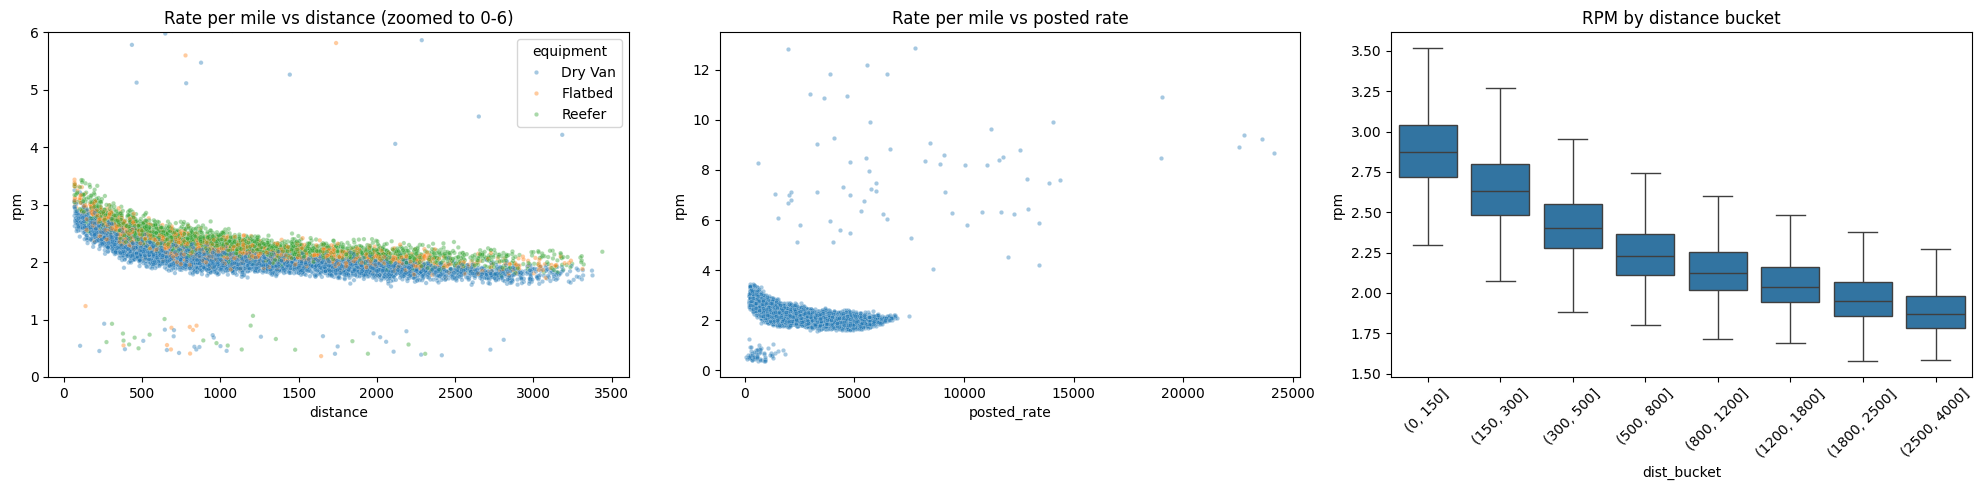

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
0.1%         0.437364
1%           1.673521
5%           1.807533
50%          2.145348
95%          2.735925
99%          3.176940
99.9%       10.068775
max         14.125294
Name: rpm, dtype: float64

rpm > 5: 317 | rpm < 1: 329

Share of rpm > 5 by distance bucket:
dist_bucket
(0, 150]        0.0083
(150, 300]      0.0102
(300, 500]      0.0068
(500, 800]      0.0060
(800, 1200]     0.0074
(1200, 1800]    0.0065
(1800, 2500]    0.0054
(2500, 4000]    0.0037
Name: rpm, dtype: float64


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df['rpm'] = df['posted_rate'] / df['distance']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# rpm vs distance, colored by equipment
sns.scatterplot(data=df.sample(10000, random_state=0), x='distance', y='rpm',
                hue='equipment', alpha=0.4, s=10, ax=axes[0])
axes[0].set_ylim(0, 6)
axes[0].set_title('Rate per mile vs distance (zoomed to 0-6)')

# rpm vs posted_rate
sns.scatterplot(data=df.sample(10000, random_state=0), x='posted_rate', y='rpm',
                alpha=0.4, s=10, ax=axes[1])
axes[1].set_title('Rate per mile vs posted rate')

# median rpm by distance bucket
df['dist_bucket'] = pd.cut(df['distance'], bins=[0, 150, 300, 500, 800, 1200, 1800, 2500, 4000])
sns.boxplot(data=df, x='dist_bucket', y='rpm', ax=axes[2], showfliers=False)
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_title('RPM by distance bucket')

plt.tight_layout()
plt.show()

# Outlier summary
print(df['rpm'].describe(percentiles=[.001, .01, .05, .95, .99, .999]))
print("\nrpm > 5:", (df['rpm'] > 5).sum(), "| rpm < 1:", (df['rpm'] < 1).sum())
print("\nShare of rpm > 5 by distance bucket:")
print(df.groupby('dist_bucket', observed=True)['rpm'].apply(lambda s: (s > 5).mean()).round(4))

In [12]:
# Overall
miss = df[['weight', 'market_index']].isna().sum()
print(miss, "\n")

# Does missingness depend on anything?
for col in ['weight', 'market_index']:
    flag = df[col].isna()
    print(f"=== Missing {col} ===")
    print("By equipment:\n", df.groupby('equipment')[col].apply(lambda s: s.isna().mean()).round(4))
    print("By month:\n", df.groupby(df['date'].dt.month)[col].apply(lambda s: s.isna().mean()).round(4))
    print("Mean posted_rate  missing vs present:",
          df.loc[flag, 'posted_rate'].mean().round(1), "vs", df.loc[~flag, 'posted_rate'].mean().round(1))
    print("Mean rpm          missing vs present:",
          df.loc[flag, 'rpm'].mean().round(3), "vs", df.loc[~flag, 'rpm'].mean().round(3))
    print("Mean distance     missing vs present:",
          df.loc[flag, 'distance'].mean().round(1), "vs", df.loc[~flag, 'distance'].mean().round(1))
    print()

# Are missing market_index values clustered on specific dates?
mi_missing_by_date = df[df['market_index'].isna()].groupby('date').size()
print("Dates with missing market_index:", len(mi_missing_by_date))
print(mi_missing_by_date.sort_values(ascending=False).head(10))

# Is market_index constant within a date? (if yes, you can fill from other rows that day)
per_day = df.groupby('date')['market_index'].agg(['nunique', 'std', 'count'])
print("\nDays where market_index varies across loads:", (per_day['std'] > 0).sum(), "of", len(per_day))

weight          300
market_index    374
dtype: int64 

=== Missing weight ===
By equipment:
 equipment
Dry Van    0.0064
Flatbed    0.0063
Reefer     0.0058
Name: weight, dtype: float64
By month:
 date
1     0.0069
2     0.0076
3     0.0071
4     0.0042
5     0.0045
6     0.0067
7     0.0059
8     0.0061
9     0.0071
10    0.0066
Name: weight, dtype: float64
Mean posted_rate  missing vs present: 2350.7 vs 2374.1
Mean rpm          missing vs present: 2.158 vs 2.216
Mean distance     missing vs present: 1145.5 vs 1135.8

=== Missing market_index ===
By equipment:
 equipment
Dry Van    0.0074
Flatbed    0.0083
Reefer     0.0082
Name: market_index, dtype: float64
By month:
 date
1     0.0073
2     0.0083
3     0.0087
4     0.0064
5     0.0088
6     0.0088
7     0.0073
8     0.0069
9     0.0066
10    0.0087
Name: market_index, dtype: float64
Mean posted_rate  missing vs present: 2392.1 vs 2373.8
Mean rpm          missing vs present: 2.187 vs 2.216
Mean distance     missing vs present: 1164.

In [15]:
from scipy.stats import chi2_contingency

# Bins so continuous variables can be tested too
df['dist_bin'] = pd.qcut(df['distance'], 5)
df['rate_bin'] = pd.qcut(df['rpm'], 5)

groupings = ['pickup', 'delivery', 'equipment', 'month', 'dow', 'dist_bin', 'rate_bin']
results = []

for col in ['weight', 'market_index']:
    flag = df[col].isna().astype(int)
    for g in groupings:
        ct = pd.crosstab(df[g], flag)
        chi2, p, _, _ = chi2_contingency(ct)
        rates = df.groupby(g, observed=True)[col].apply(lambda s: s.isna().mean())
        results.append({
            'column': col,
            'tested_against': g,
            'groups': len(rates),
            'min_missing_rate': round(rates.min(), 4),
            'max_missing_rate': round(rates.max(), 4),
            'p_value': round(p, 3),
            'random?': 'yes' if p > 0.05 else 'NO - investigate'
        })

res = pd.DataFrame(results)
display(res)

# Missing values scattered across dates, and independent of each other
mi = df[df['market_index'].isna()]
print("Dates with a missing market_index:", mi['date'].nunique(), "| max per day:", mi.groupby('date').size().max())
print("Rows missing both weight and market_index:", (df['weight'].isna() & df['market_index'].isna()).sum())

,column,tested_against,groups,min_missing_rate,max_missing_rate,p_value,random?
0,weight,pickup,64,0.0000,0.0165,0.926,yes
1,weight,delivery,64,0.0000,0.0145,0.235,yes
2,weight,equipment,3,0.0058,0.0064,0.770,yes
3,weight,month,10,0.0042,0.0076,0.432,yes
4,weight,dow,7,0.0047,0.0070,0.458,yes
5,weight,dist_bin,5,0.0057,0.0069,0.826,yes
6,weight,rate_bin,5,0.0054,0.0071,0.636,yes
7,market_index,pickup,64,0.0000,0.0149,0.246,yes
8,market_index,delivery,64,0.0000,0.0137,0.816,yes
9,market_index,equipment,3,0.0074,0.0083,0.578,yes


Dates with a missing market_index: 209 | max per day: 5
Rows missing both weight and market_index: 1


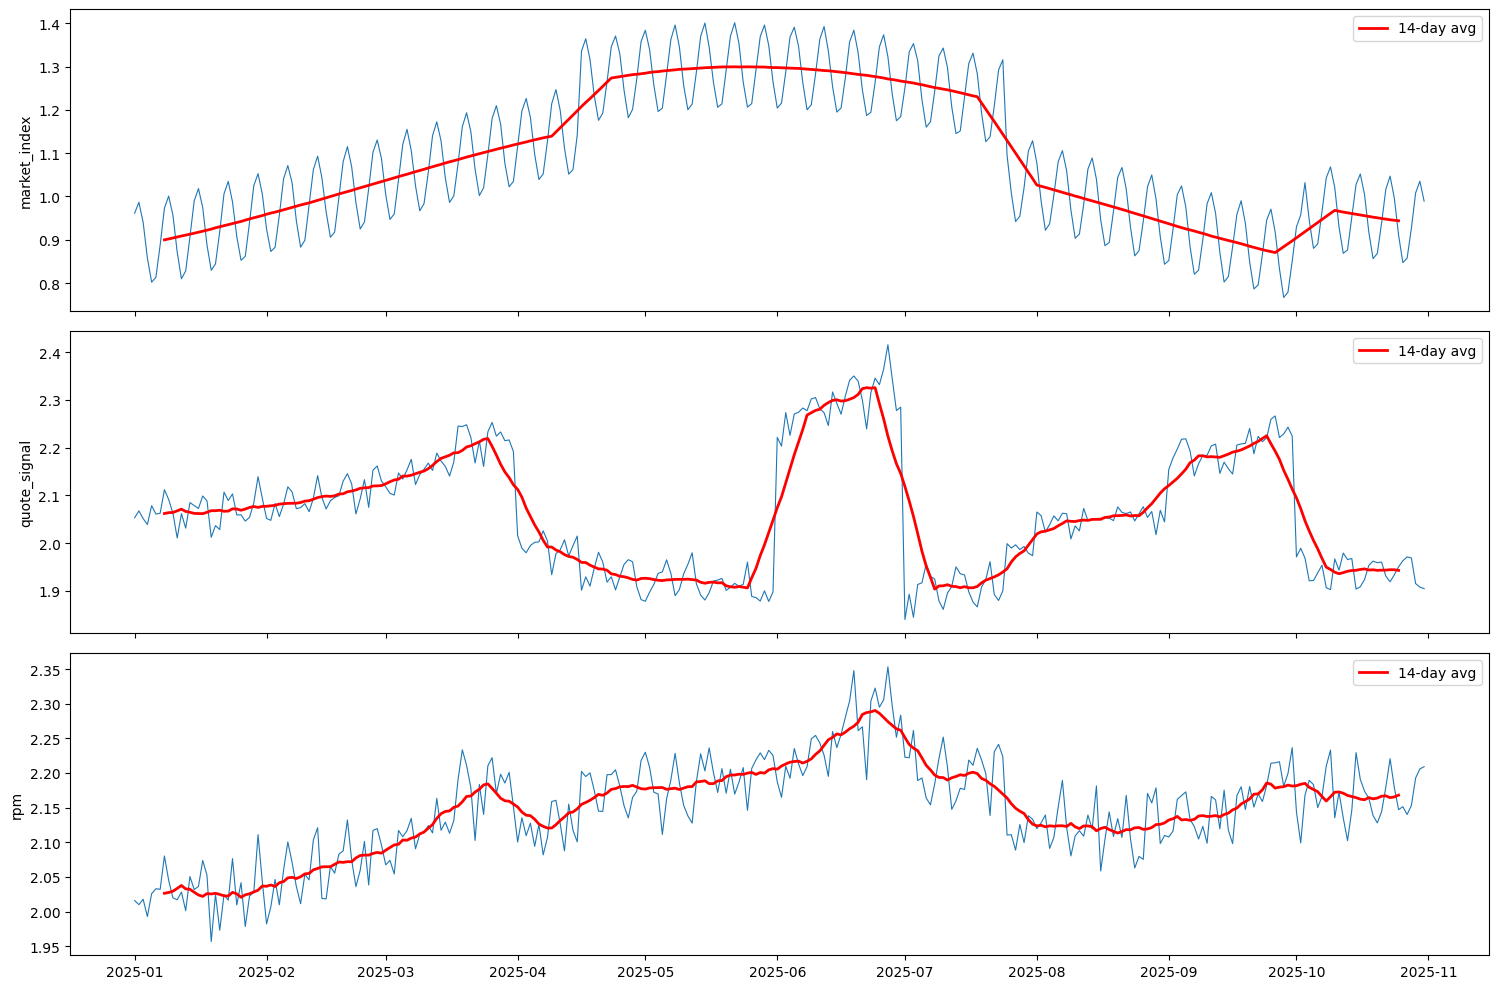

     market_index  quote_signal    rpm
dow                                   
0           1.000         2.073  2.196
1           1.075         2.066  2.213
2           1.153         2.052  2.248
3           1.179         2.059  2.245
4           1.134         2.059  2.215
5           1.047         2.059  2.196
6           0.989         2.069  2.192
       market_index  quote_signal    rpm
month                                   
1             0.927         2.068  2.100
2             0.996         2.097  2.123
3             1.073         2.180  2.206
4             1.208         1.963  2.210
5             1.301         1.913  2.260
6             1.280         2.296  2.332
7             1.201         1.923  2.256
8             0.981         2.052  2.189
9             0.893         2.200  2.230
10            0.958         1.943  2.240

Correlation with rpm:
              market_index  quote_signal    rpm
market_index         1.000        -0.159  0.642
quote_signal        -0.159         1.0

In [13]:
daily = df.groupby('date').agg(
    market_index=('market_index', 'mean'),
    quote_signal=('quote_signal', 'mean'),
    rpm=('rpm', 'median'),
    n=('load_id', 'count')
)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
for ax, col in zip(axes, ['market_index', 'quote_signal', 'rpm']):
    ax.plot(daily.index, daily[col], lw=0.8)
    ax.plot(daily.index, daily[col].rolling(14, center=True).mean(), lw=2, color='red', label='14-day avg')
    ax.set_ylabel(col); ax.legend()
plt.tight_layout(); plt.show()

# Weekly / monthly seasonality
df['dow'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
print(df.groupby('dow')[['market_index', 'quote_signal', 'rpm']].mean().round(3))
print(df.groupby('month')[['market_index', 'quote_signal', 'rpm']].mean().round(3))

# Do they actually explain rpm, controlling for equipment?
print("\nCorrelation with rpm:")
print(daily[['market_index', 'quote_signal', 'rpm']].corr().round(3))

# Range check: what values would December need to extrapolate to?
print("\nmarket_index range:", df['market_index'].min(), df['market_index'].max())
print("Last 30 days of data:\n", daily.tail(30)[['market_index', 'quote_signal']].describe().round(3))